# Healthcare DS Class Project

Savanna Cabrera, Manuel Sanchez, Sienna Lee

## EDA Analysis

Note. I am performing EDA analysis on my beloved VSCode notebook before I try to do it in Tableau. Tableau is more "on-rails", so this is to make sure I have enough background to know which graphs I would like to try and run.


The question: Among submitted GLP-1-related reports, which patient, drug, and report characteristics are associated with recorded hospitalization? I also want to compare reports with and without medication-use problems once that definition is settled.


The audience is the medical-safety team responsible for patient education and follow-up. These patterns can point us toward topics worth investigating. They do not tell us that a drug caused the event, estimate hospitalization risk among all users, or prove that education would prevent hospitalization.
One row in df is a drug-report match. One row in reports is a distinct report ID, not necessarily a distinct patient or event.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [30]:
file_name = "glp1_faers_complete_2018_2025.csv"

df = pd.read_csv(
    file_name,
    low_memory=False,
    dtype={
        "safetyreportid": "string",
        "matching_routes": "string"
    }
) #preserve the drug-report table for drug-specific analysis

assert df["ingredient_query"].notna().all() # We need a matched ingredient on every row.
assert df["safetyreportid"].notna().all() # We need an ID on every row to group and deduplicate reports correctly.
assert df["safetyreportversion"].notna().all() # We need a version value to identify the latest available report version.
assert df["hospitalized"].notna().all() # Missing labels should be investigated rather than silently treated as 0.
assert df["hospitalized"].isin([0, 1]).all() ## Binary values are required for the planned binary classification model.

#Apply the same date conversion to both date columns. 
for column in ["receivedate", "receiptdate"]:
    # Replace the current column with pandas datetime values
    df[column] = pd.to_datetime(
        df[column].astype(str),
        format="%Y%m%d", #yearmonthday
        errors="coerce" #convert invalid dates to NaT (missing values)
    )

#Stop if any date could not be parsed. We need valid dates for the time analysis.
assert df[["receivedate", "receiptdate"]].notna().all().all(), "Check missing or invalid dates."

df["report_year"] = df["receivedate"].dt.year #extract the year from the receivedate column

df["age_clean"] = df["patient_age_years"].where(
    df["patient_age_years"].between(0, 120)
) # Filter out invalid age values

# Retain all ingredient rows belonging to the latest available
# find the latest available version of each report.
latest_version = (
    df.groupby("safetyreportid")["safetyreportversion"]
      .transform("max") 
) #Group rows representing the same available report info in the CSV

latest_rows = df.loc[
    df["safetyreportversion"].eq(latest_version)
].copy() #Keep every ingredient row belonging to the latest version of each report. Keeping all matching ingredients prevents losing multi-drug information.

assert not latest_rows.duplicated(
    ["safetyreportid", "ingredient_query"]
).any() #check that each report/ingredient pair appears max once; duplicates would inflate counts

# ID columns that can differ across ingredient rows for one report. These should not be carried forward from a randomly selected row.
drug_specific_columns = [
    "ingredient_query", #ingredient used in the API query
    "matching_medicinal_products", #Product names matching that ingredient
    "matching_indications", #Indications for the match drugs
    "matching_routes", #Routes of administration for the match drugs
    "matching_drug_roles" #Roles of the match drugs
]

# ID the columns expected to describe the report as a whole.
# Values should agree across ingredient rows for one report.
shared_columns = [
    c for c in latest_rows.columns
    if c not in drug_specific_columns + ["safetyreportid"] #exclude drug-specific columns and the report ID
]
#select reports represented by multiple ingredient rows.
#these are the reports where we need to check agreement before collapsing
multiple_rows = latest_rows.loc[
    latest_rows["safetyreportid"].duplicated(keep=False)
]

conflicts = (
    multiple_rows.groupby("safetyreportid")[shared_columns]
    .nunique(dropna=False)
    .gt(1)
) #this makes a table showing if any shared fields disagree

assert not conflicts.to_numpy().any(), (
    "Some report-level fields disagree across ingredient rows."
) #this stops if any shared report disagrees across ingredient rows

reports = (
    latest_rows
    .drop_duplicates("safetyreportid")
    .drop(columns=drug_specific_columns)
    .set_index("safetyreportid")
) #this creates a table containing one row per report ID

# Each drug gets its own presence indicator.
# Reports can have more than one indicator equal to 1.
drug_flags = (
    pd.crosstab(
        latest_rows["safetyreportid"],
        latest_rows["ingredient_query"]
    )
    .gt(0)
    .astype("int8")
    .add_prefix("drug_")
) #create one binary presence column for each selected ingredient. A report can have several drug columns equal to 1.

reports = (
    reports.join(drug_flags, validate="one_to_one")
    .reset_index()
)

assert reports["safetyreportid"].is_unique

#print da results
print("Drug-report rows:", len(df))
print("Distinct report IDs:", len(reports))
print("Hospitalization recorded:", reports["hospitalized"].sum())
print(
    "Hospitalization recorded (%):",
    round(reports["hospitalized"].mean() * 100, 2)
)

Drug-report rows: 281871
Distinct report IDs: 276902
Hospitalization recorded: 33137
Hospitalization recorded (%): 11.97


In [31]:
#Review column names and data types
print(df.columns.tolist())
df.dtypes


['ingredient_query', 'safetyreportid', 'safetyreportversion', 'receivedate', 'receiptdate', 'occurcountry', 'primarysourcecountry', 'reporter_qualification', 'serious', 'hospitalized', 'death', 'life_threatening', 'disabling', 'congenital_anomaly', 'other_serious', 'patient_age', 'patient_age_unit', 'patient_age_years', 'patient_sex', 'patient_weight_kg', 'matching_medicinal_products', 'matching_indications', 'matching_routes', 'matching_drug_roles', 'reaction_terms', 'n_reactions', 'n_drugs_in_report', 'report_year', 'age_clean']


ingredient_query                       object
safetyreportid                 string[python]
safetyreportversion                     int64
receivedate                    datetime64[ns]
receiptdate                    datetime64[ns]
occurcountry                           object
primarysourcecountry                   object
reporter_qualification                 object
serious                                 int64
hospitalized                            int64
death                                   int64
life_threatening                        int64
disabling                               int64
congenital_anomaly                      int64
other_serious                           int64
patient_age                           float64
patient_age_unit                      float64
patient_age_years                     float64
patient_sex                            object
patient_weight_kg                     float64
matching_medicinal_products            object
matching_indications              

## Double-Checking the Cleanup:
The cleanup is already done above. I am checking the results here, not building reports all over again. That would overwrite the drug indicators we just made.

In [32]:
#Check da results without redoing the cleanup
print("Latest-version drug-report rows:", len(latest_rows))
print("Extra ingredient rows:", len(latest_rows) - len(reports))
print("Reports matching multiple selected drugs:",
      drug_flags.sum(axis=1).gt(1).sum())
print("Duplicate drug/report pairs:",
      latest_rows.duplicated(["ingredient_query", "safetyreportid"]).sum())
print("Invalid ages changed to missing:",
      (reports["patient_age_years"].notna() & reports["age_clean"].isna()).sum())
print("Original received dates:", reports["receivedate"].min(), "to", reports["receivedate"].max())
print("Receipt/update dates:", reports["receiptdate"].min(), "to", reports["receiptdate"].max())

Latest-version drug-report rows: 281871
Extra ingredient rows: 4969
Reports matching multiple selected drugs: 4388
Duplicate drug/report pairs: 0
Invalid ages changed to missing: 2
Original received dates: 2018-01-01 00:00:00 to 2025-12-31 00:00:00
Receipt/update dates: 2018-01-01 00:00:00 to 2026-06-30 00:00:00


## Check missing data


Missing values across distinct report IDs (%):
patient_weight_kg         88.31
age_clean                 40.96
occurcountry               2.98
reporter_qualification     0.45
patient_sex                0.00
n_reactions                0.00
n_drugs_in_report          0.00
dtype: float64


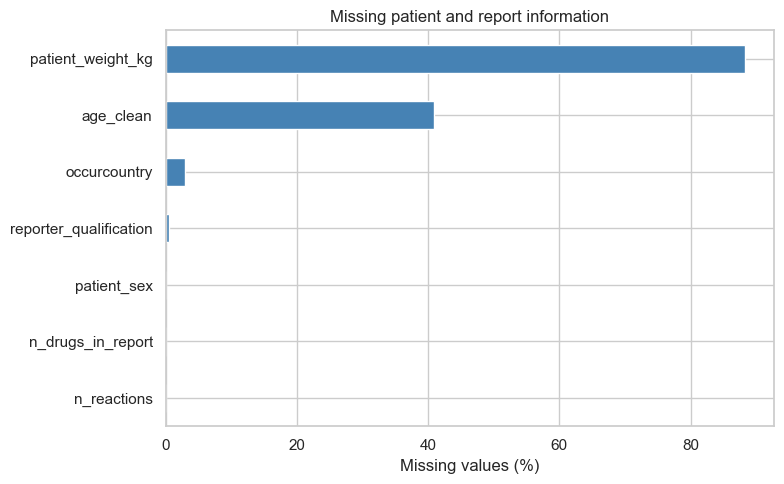


Missing values across drug-report rows (%):
matching_routes         14.84
matching_indications     7.28
matching_drug_roles      0.00
dtype: float64

Sex recorded as Unknown (%): 13.08


In [33]:
#Use reports for patient/report fields so each report is counted once
columns_to_check = [
    "age_clean", "patient_sex", "patient_weight_kg",
    "reporter_qualification", "occurcountry", "n_reactions", "n_drugs_in_report"
]

missing = (
    reports[columns_to_check].isna().mean().mul(100).sort_values(ascending=False)
)
print("Missing values across distinct report IDs (%):")
print(missing.round(2))

plt.figure(figsize=(8, 5))
missing.sort_values().plot(kind="barh", color="steelblue")
plt.xlabel("Missing values (%)")
plt.title("Missing patient and report information")
plt.tight_layout()
plt.show()

#Drug-specific fields stay in latest_rows; these have a different denominator
drug_missing = (
    latest_rows[["matching_indications", "matching_routes", "matching_drug_roles"]]
    .isna().mean().mul(100).sort_values(ascending=False)
)
print("\nMissing values across drug-report rows (%):")
print(drug_missing.round(2))

#Unknown is already a category here, so isna() does not count it
print("\nSex recorded as Unknown (%):",
      round(reports["patient_sex"].eq("Unknown").mean() * 100, 2))


Note that patient weight has an extremely large amount of missing values (about 88%). I am leaving it out of the first model. 

Age is missing in about 41% of reports, but I do not need to throw it out yet. I can fill missing age using the training-set median and include an indicator for missing age.

Sex has no NA values here, but some reports say "Unknown". That's still missing information, just stored as a category. Considering the existance of trans and intersex patients, I will keep this in the dataset.

## Investigating Response Variable: Hospitalizations

Here, 1 means hospitalization was recorded. I am calling 0 "not recorded", since it should not be treated as proof that hospitalization never happened. The API extraction needs to confirm how absent hospitalization fields were mapped to 0.

Counts:
hospitalized
0    243765
1     33137
Name: count, dtype: int64

Percent:
hospitalized
0    88.03
1    11.97
Name: proportion, dtype: float64


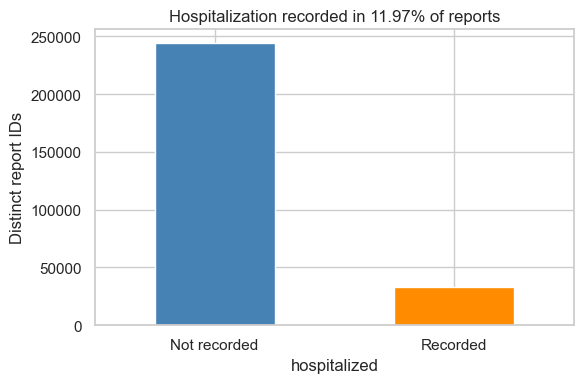

In [36]:
target_counts = reports["hospitalized"].value_counts().sort_index()
target_pct = reports["hospitalized"].value_counts(normalize=True).sort_index() * 100

print("Counts:")
print(target_counts)
print("\nPercent:")
print(target_pct.round(2))

plt.figure(figsize=(6, 4))
target_counts.rename(index={0: "Not recorded", 1: "Recorded"}).plot(
    kind="bar", color=["steelblue", "darkorange"], rot=0
)
plt.ylabel("Distinct report IDs")
plt.title(f"Hospitalization recorded in {reports['hospitalized'].mean():.2%} of reports")
plt.tight_layout()
plt.show()


## Let's see the report patterns across drugs


In [37]:
drug_summary = (
    latest_rows.groupby("ingredient_query")["hospitalized"]
      .agg(reports="count", hospitalizations="sum", hospitalization_rate="mean")
      .sort_values("reports", ascending=False)
)
drug_summary["hospitalization_pct"] = drug_summary["hospitalization_rate"] * 100

drug_summary[["reports", "hospitalizations", "hospitalization_pct"]].round(2)

,reports,hospitalizations,hospitalization_pct
ingredient_query,,,
Tirzepatide,121302,7463,6.15
Dulaglutide,73876,8942,12.10
Semaglutide,60958,12487,20.48
Liraglutide,20042,5433,27.11
Lixisenatide,3098,207,6.68
Exenatide,2595,544,20.96


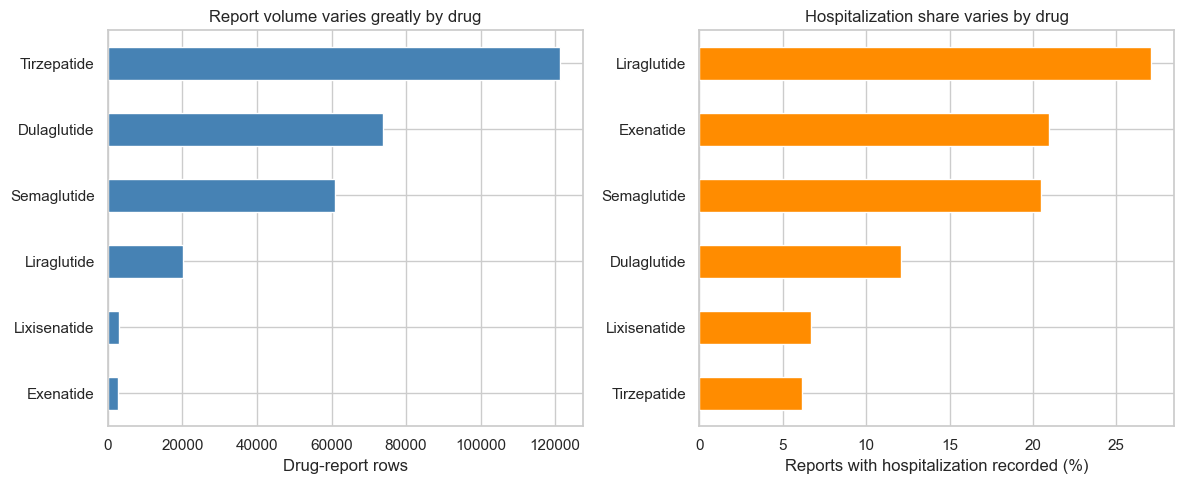

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

drug_summary["reports"].sort_values().plot(
    kind="barh", ax=axes[0], color="steelblue"
)
axes[0].set_xlabel("Drug-report rows")
axes[0].set_ylabel("")
axes[0].set_title("Report volume varies greatly by drug")

drug_summary["hospitalization_pct"].sort_values().plot(
    kind="barh", ax=axes[1], color="darkorange"
)
axes[1].set_xlabel("Reports with hospitalization recorded (%)")
axes[1].set_ylabel("")
axes[1].set_title("Hospitalization share varies by drug")

plt.tight_layout()
plt.show()

From what I see in the two graphs, Tirzepatide has by FAR the most reports, but a smaller share listing hospitalization than the other drugs. Liraglutide has fewer reports and a higher hospitalization share.

I need to keep counts and percentages separate here. This is not a ranking of drug safety. Different patient groups, reporting patterns, and years could explain part of the difference. Also, a report listing multiple selected drugs contributes to multiple drug groups.

## Time analysis


In [39]:
year_summary = (
    reports.groupby("report_year")["hospitalized"]
           .agg(reports="count", hospitalization_rate="mean")
)
year_summary["hospitalization_pct"] = year_summary["hospitalization_rate"] * 100

year_summary.round(2)


,reports,hospitalization_rate,hospitalization_pct
report_year,,,
2018,13978,0.15,14.59
2019,14777,0.17,16.67
2020,17429,0.15,15.44
2021,19952,0.15,14.62
2022,24726,0.12,11.82
2023,41668,0.10,9.71
2024,55762,0.11,11.12
2025,88610,0.11,11.12


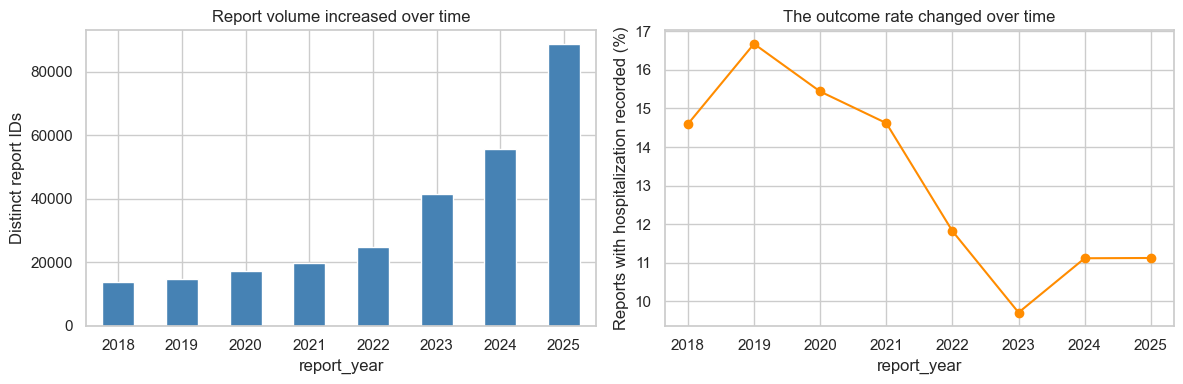

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

year_summary["reports"].plot(
    kind="bar", ax=axes[0], color="steelblue", rot=0
)
axes[0].set_ylabel("Distinct report IDs")
axes[0].set_title("Report volume increased over time")

year_summary["hospitalization_pct"].plot(
    marker="o", ax=axes[1], color="darkorange"
)
axes[1].set_ylabel("Reports with hospitalization recorded (%)")
axes[1].set_title("The outcome rate changed over time")

plt.tight_layout()
plt.show()

Note that FDA report volume rose over time, but this doesn't mean the drugs became more dangerous. More use, more attention, or different reporting patterns could contribute; this file does not measure how many people used each drug.

The hospitalization share was lower in later years than in 2018–2019, but it did not decrease every single year. That changing mix is one reason I want to test on later reports.

## Drug Composition by Year

How did the mix of reported drugs change over time? This graph shows the share of drug-report rows, not prescriptions or market share.

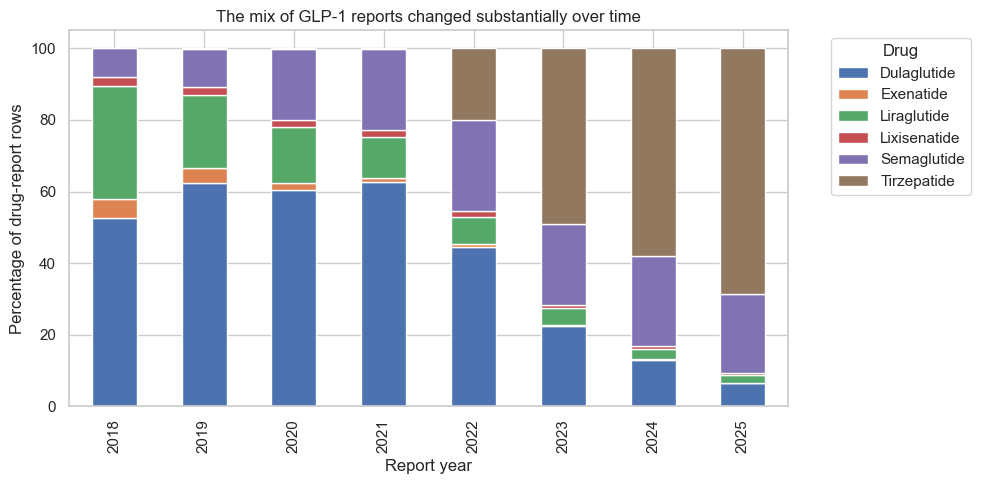

In [41]:
drug_by_year = pd.crosstab(
    latest_rows["report_year"],
    latest_rows["ingredient_query"],
    normalize="index"
) * 100

drug_by_year.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.ylabel("Percentage of drug-report rows")
plt.xlabel("Report year")
plt.title("The mix of GLP-1 reports changed substantially over time")
plt.legend(title="Drug", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## Exploring Patient Age and Sex
Weight is too incomplete for my first model. Age and sex are still worth checking, including how much information is missing.

patient_sex
Female     161406
Male        79264
Unknown     36232
Name: count, dtype: int64

Age summary:
count    163489.0
mean         57.5
std          13.9
min           0.0
25%          48.0
50%          59.0
75%          68.0
max         104.0
Name: age_clean, dtype: float64


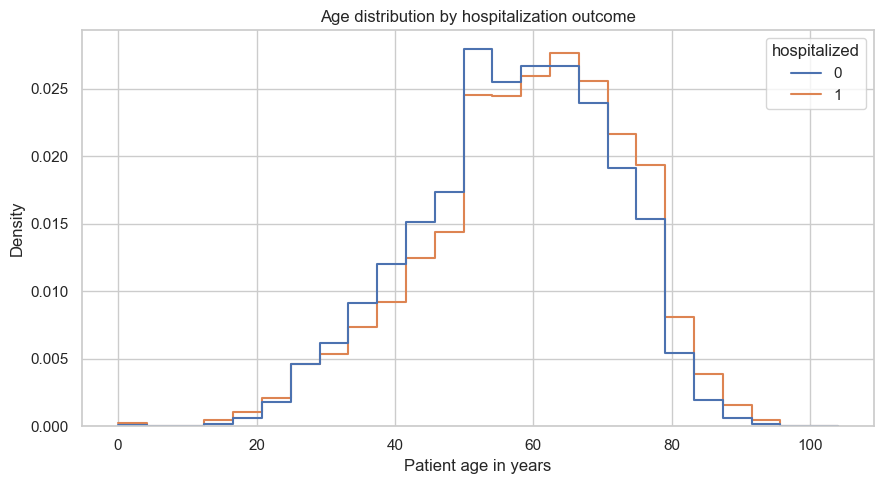

In [42]:
print(reports["patient_sex"].value_counts(dropna=False))
print("\nAge summary:")
print(reports["age_clean"].describe().round(1))

plt.figure(figsize=(9, 5))
sns.histplot(
    data=reports,
    x="age_clean",
    hue="hospitalized",
    bins=25,
    stat="density",
    common_norm=False,
    element="step",
    fill=False
)
plt.xlabel("Patient age in years")
plt.title("Age distribution by hospitalization outcome")
plt.tight_layout()
plt.show()


The age distributions overlap, so age alone will not cleanly separate the outcomes. I have not run a significance test here, so I cannot say the groups do or do not differ significantly. The summary above describes reports with known, plausible ages; it leaves out reports with missing age.

## Hospitalizations by Age Group

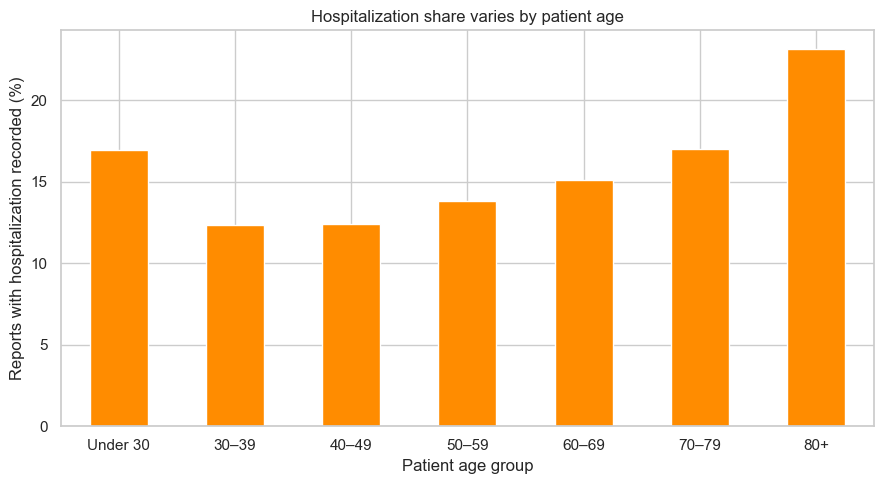

In [43]:
reports["age_group"] = pd.cut(
    reports["age_clean"],
    bins=[0, 30, 40, 50, 60, 70, 80, np.inf],
    labels=["Under 30", "30–39", "40–49", "50–59",
            "60–69", "70–79", "80+"],
    right=False #keep fractional ages like 29.5 in Under 30
)

age_summary = (
    reports.groupby("age_group", observed=True)["hospitalized"]
    .agg(reports="count", hospitalization_rate="mean")
)

age_summary["hospitalization_pct"] = (
    age_summary["hospitalization_rate"] * 100
)

age_summary["hospitalization_pct"].plot(
    kind="bar",
    figsize=(9, 5),
    color="darkorange",
    rot=0
)

plt.ylabel("Reports with hospitalization recorded (%)")
plt.xlabel("Patient age group")
plt.title("Hospitalization share varies by patient age")
plt.tight_layout()
plt.show()

## Explore how reporter type fits into this, if any.

In [44]:
reporter_summary = (
    reports.assign(
        reporter=reports["reporter_qualification"].fillna("Unknown")
    )
    .groupby("reporter")["hospitalized"]
    .agg(reports="count", hospitalization_rate="mean")
)
reporter_summary["hospitalization_pct"] = reporter_summary["hospitalization_rate"] * 100

reporter_summary.sort_values("reports", ascending=False).round(2)

,reports,hospitalization_rate,hospitalization_pct
reporter,,,
Consumer/non-health professional,226723,0.08,8.26
Physician,21624,0.30,30.00
Other health professional,18108,0.23,22.86
Pharmacist,7570,0.33,33.39
Lawyer,1619,0.54,53.86
Unknown,1258,0.31,30.92


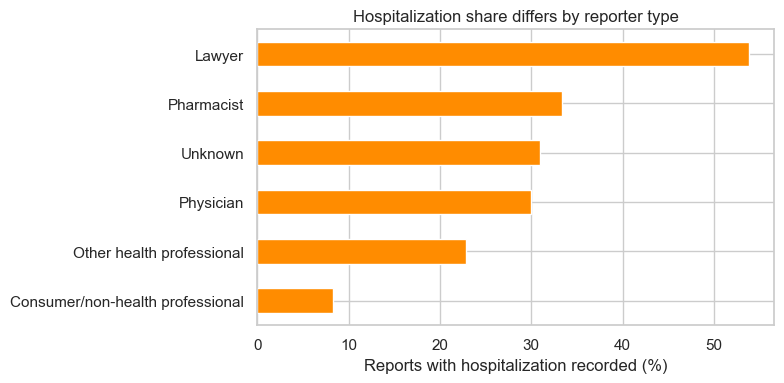

In [45]:
reporter_summary["hospitalization_pct"].sort_values().plot(
    kind="barh", figsize=(8, 4), color="darkorange"
)
plt.xlabel("Reports with hospitalization recorded (%)")
plt.ylabel("")
plt.title("Hospitalization share differs by reporter type")
plt.tight_layout()
plt.show()


Lawyer-submitted reports have a high hospitalization share in this table. That does not tell me who usually submits all hospitalization reports, or that the drug caused hospitalization. I need to check the counts along with the percentages.

Reporter qualification has very little NA data here, so I am keeping it for the baseline. It may tell us something about reporting behavior as well as the events being reported.LMAO. When a drug causes hospitalization, a lawyer usually fills out the FAERs report, which makes sense. Then it's Pharmacist. Though there's a lot of unknowns here so it may behoove us to ignore reporter column. 

## Hospitalization by drug role
Was the matched drug listed as suspect, concomitant, or interacting? These are reported roles, not confirmed causes. A combined label means multiple roles were present for the matched drug entries.

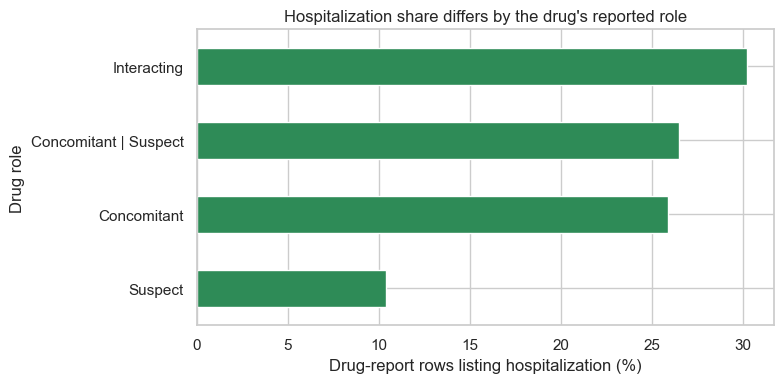

In [46]:
role_summary = (
    latest_rows.groupby("matching_drug_roles")["hospitalized"]
    .agg(reports="count", hospitalization_rate="mean")
)

# Keep categories with at least 100 reports
role_summary = role_summary[role_summary["reports"] >= 100]
role_summary["hospitalization_pct"] = (
    role_summary["hospitalization_rate"] * 100
)

role_summary["hospitalization_pct"].sort_values().plot(
    kind="barh",
    figsize=(8, 4),
    color="seagreen"
)

plt.xlabel("Drug-report rows listing hospitalization (%)")
plt.ylabel("Drug role")
plt.title("Hospitalization share differs by the drug's reported role")
plt.tight_layout()
plt.show()

Lots of interacting medications causing issues. Does this track with report complexity?

## Report Complexity versus Hospitalization

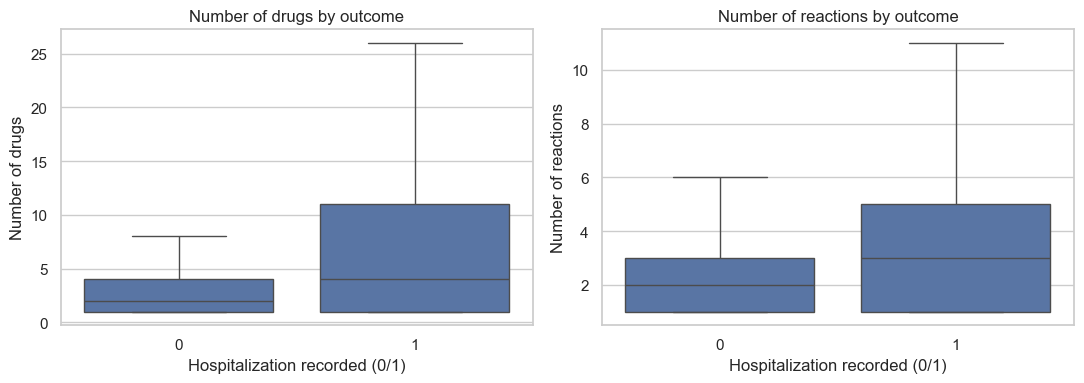

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(
    data=reports,
    x="hospitalized",
    y="n_drugs_in_report",
    showfliers=False,
    ax=axes[0]
)
axes[0].set_xlabel("Hospitalization recorded (0/1)")
axes[0].set_ylabel("Number of drugs")
axes[0].set_title("Number of drugs by outcome")

sns.boxplot(
    data=reports,
    x="hospitalized",
    y="n_reactions",
    showfliers=False,
    ax=axes[1]
)
axes[1].set_xlabel("Hospitalization recorded (0/1)")
axes[1].set_ylabel("Number of reactions")
axes[1].set_title("Number of reactions by outcome")

plt.tight_layout()
plt.show()

Reports listing hospitalization tend to include more drugs and reaction terms, but the distributions overlap. These counts may also reflect how thoroughly an event was documented. I am keeping them for an extended model rather than treating them as information available before hospitalization. The boxplots hide outliers to make the main distributions easier to see; those rows are still in the data.

Keep in mind, the more drugs a person takes, the sicker that person is generally. May not be a helpful clue.

In [48]:
reports.groupby("hospitalized")[
    ["n_drugs_in_report", "n_reactions"]
].agg(["count", "median", "mean", "std"]).round(2)

n_drugs_in_report                     n_reactions               \
                         count median  mean    std       count median  mean   
hospitalized                                                                  
0                       243765    2.0  4.31   6.41      243765    2.0  2.44   
1                        33137    4.0  9.14  24.70       33137    3.0  4.39   

                    
               std  
hospitalized        
0             2.47  
1             5.47

## Common reaction terms
This is where I suspect the meat of the data is.

reaction_terms
Incorrect dose administered                         31904
Nausea                                              30269
Injection site pain                                 22174
Diarrhoea                                           17666
Vomiting                                            16457
Off label use                                       16330
Blood glucose increased                             15588
Extra dose administered                             11303
Constipation                                         9992
Decreased appetite                                   9660
Weight decreased                                     9199
Drug ineffective                                     9193
Fatigue                                              8833
Injection site haemorrhage                           7899
Inappropriate schedule of product administration     7627
Name: count, dtype: int64


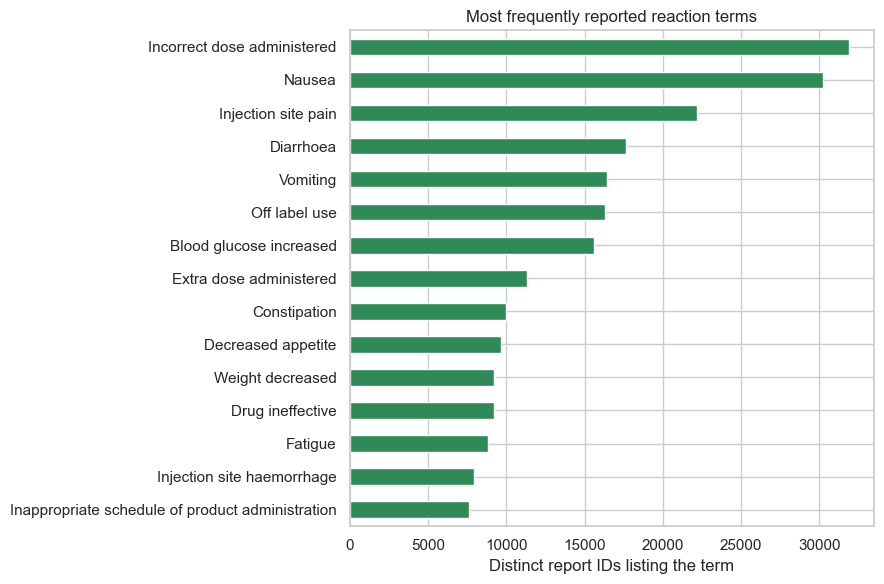

In [49]:
#Count a reaction term at most once in each report
reaction_sets = reports["reaction_terms"].fillna("").map(
    lambda text: {term.strip() for term in text.split("|") if term.strip()}
)

reaction_counts = reaction_sets.explode().dropna().value_counts()
top_reactions = reaction_counts.head(15)
print(top_reactions)

top_reactions.sort_values().plot(
    kind="barh", figsize=(9, 6), color="seagreen"
)
plt.xlabel("Distinct report IDs listing the term")
plt.ylabel("")
plt.title("Most frequently reported reaction terms")
plt.tight_layout()
plt.show()


## One Last thing....
The multi-drug issue is handled now. reports keeps one row per report ID and a separate 0/1 column for each selected drug. Indications, routes, and roles stay in latest_rows, where they are still attached to the matched ingredient.
I should not use a single ingredient_query from a deduped row as though it were the only drug in the report.

## Medication-use problems:
This is where I suspect the meat of the data is. The notebook so far includes all selected GLP-1 reports. I still need to decide which exact terms count as medication-use problems before fitting that part of the analysis.

The search below is just to find candidate terms, not to create the final flag. For example, "Administration site pain" should not become a medication error just because it contains "administration". I also need to decide how to handle intentional misuse, intercepted errors, and off-label use. These are report-level reaction terms, so they do not prove the problem involved the matched GLP-1 drug.

In [50]:
#Look at possible terms and their report counts before choosing a definition
medication_use_candidates = reaction_counts.loc[
    reaction_counts.index.str.contains(
        "dose|dosing|administration|medication error|wrong|incorrect|misuse|overdose|underdose",
        case=False,
        regex=True
    )
].rename_axis("reaction_term").to_frame("reports")

medication_use_candidates.head(60)

,reports
reaction_term,
Incorrect dose administered,31904
Extra dose administered,11303
Inappropriate schedule of product administration,7627
Product dose omission issue,7419
Accidental underdose,6836
Wrong technique in product usage process,4502
Accidental overdose,3779
Overdose,1334
Underdose,1261


## Final Prep for Logistic Regression, our Baseline Model
For now, this is an all-report baseline. The medication-use definition is still a separate decision; I have not silently picked a list of terms or labeled reports without a match as definitely free of medication-use problems.

I am starting with age, sex, reporter qualification, country of occurrence, and the six drug indicators. I am leaving weight out because it is mostly missing. I am also leaving reaction terms and report-complexity counts out of the first model.

hospitalized is the target. serious and the other seriousness outcomes are not predictors. IDs and report versions are not predictors either. Year is used for splitting here, not as a baseline predictor. I am splitting the data by year because I want to see whether the model holds up on later reports, especially since the drug mix and reporting patterns change over time. A random split would put reports from every year into both training and testing, which could make the model look better without really answering that question. I will train on 2018–2023, use 2024 to choose model settings, and then refit on 2018–2024 before testing on 2025. If performance drops on the later reports, that's still useful information: it tells us that the earlier patterns may not carry forward as well as we hoped. One catch is that this file includes updated report versions, so the split compares original received-year groups rather than recreating exactly what was known at each cutoff.

In [52]:
#Make a separate modeling table so EDA data stays as-is
model_data = reports.copy()

numeric_features = ["age_clean"]
categorical_features = ["patient_sex", "reporter_qualification", "occurcountry"]
binary_features = drug_flags.columns.tolist()
features = numeric_features + categorical_features + binary_features

#Unknown is a fixed category; this does not learn anything from later reports
model_data[categorical_features] = model_data[categorical_features].fillna("Unknown")

#Keep earlier reports for training and later reports for validation/testing
assert model_data["report_year"].between(2018, 2025).all()
train = model_data.loc[model_data["report_year"].between(2018, 2023)].copy()
validation = model_data.loc[model_data["report_year"].eq(2024)].copy()
test = model_data.loc[model_data["report_year"].eq(2025)].copy()

X_train, y_train = train[features], train["hospitalized"]
X_validation, y_validation = validation[features], validation["hospitalized"]
X_test, y_test = test[features], test["hospitalized"]

#Make sure no report ID crosses between the splits
assert set(train["safetyreportid"]).isdisjoint(validation["safetyreportid"])
assert set(train["safetyreportid"]).isdisjoint(test["safetyreportid"])
assert set(validation["safetyreportid"]).isdisjoint(test["safetyreportid"])
assert len(train) + len(validation) + len(test) == len(model_data)

split_summary = pd.DataFrame({
    "reports": [len(train), len(validation), len(test)],
    "hospitalization_pct": [
        y_train.mean() * 100, y_validation.mean() * 100, y_test.mean() * 100
    ]
}, index=["Train: 2018–2023", "Validation: 2024", "Test: 2025"])

split_summary.round(2)

,reports,hospitalization_pct
Train: 2018–2023,132530,12.89
Validation: 2024,55762,11.12
Test: 2025,88610,11.12


### A catch with the time split
The original received dates run from 2018 to 2025, but some receipt/update dates extend into 2026. That means these are available updated records grouped by original received year, not snapshots of exactly what was known at the historical cutoff. I need to say that in the report. A strictly prospective evaluation would need the versions available at each cutoff.

In [53]:
#Check how many earlier reports were updated after their split cutoff
print("Training reports with receipt/update dates after 2023:",
      train["receiptdate"].gt(pd.Timestamp("2023-12-31")).sum())
print("Validation reports with receipt/update dates after 2024:",
      validation["receiptdate"].gt(pd.Timestamp("2024-12-31")).sum())

Training reports with receipt/update dates after 2023: 9005
Validation reports with receipt/update dates after 2024: 2813


In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

#Fill age using the training median, flag missing age, then scale
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

#Encode categories and carry the drug indicators through as 0/1 values
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("drug_flags", "passthrough", binary_features)
])

#Keep preprocessing and the model together so they fit on training data only
#This sets up the baseline; I am not fitting it yet
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("logistic_regression", LogisticRegression(max_iter=2000))
])

print("Baseline features:", features)
print("Baseline pipeline is set up. It has not been fitted yet.")

Baseline features: ['age_clean', 'patient_sex', 'reporter_qualification', 'occurcountry', 'drug_Dulaglutide', 'drug_Exenatide', 'drug_Liraglutide', 'drug_Lixisenatide', 'drug_Semaglutide', 'drug_Tirzepatide']
Baseline pipeline is set up. It has not been fitted yet.


## Next Steps

For the all-report baseline, the next step is baseline_model.fit(X_train, y_train). The pipeline learns its median, scaling, categories, and coefficients from training data only. I will use 2024 for tuning and threshold choices, then evaluate the final model on 2025 once. Since I have already looked at all years in EDA, the 2025 set is a held-out evaluation set within this explored dataset, not a completely unseen external dataset.
I want a dummy classifier for comparison, average precision, ROC-AUC, precision/recall, a confusion matrix, and calibration. Accuracy alone is not enough when only about 12% of reports list hospitalization. I will start with the default unweighted logistic regression before trying class weights, and check calibration if I change the weights.
The coefficients describe adjusted associations within these reports. They do not establish drug causation or hospitalization risk among all GLP-1 users.